### Setup Data loader

In [11]:
import gpytorch
import torch

from agent.components.commons import ServiceFeatureMapping, ServiceType
from notebooks.create_deepGP import get_prepared_metrics_df, ServiceGP, prepare_chained_data

torch.set_default_dtype(torch.float64)

converted_df = get_prepared_metrics_df()

QR_MAP = ServiceFeatureMapping(ServiceType.QR, [0, 1])
CV_MAP = ServiceFeatureMapping(ServiceType.CV, [2, 3, 4])
PC_MAP = ServiceFeatureMapping(ServiceType.PC, [5, 6])

chain_definition = [QR_MAP, CV_MAP, PC_MAP]

# train_loader, test_x, test_y, scaler_X = prepare_chained_data(converted_df, test_size=0.2)
train_loader, test_x, test_y, scaler_X = prepare_chained_data(converted_df, chain_definition, test_size=0.2)


### Setup the Structure


In [12]:

class StaticServiceChain(torch.nn.Module):
    """Connects 3 GPs into a chain where outputs of one become inputs to the next."""

    def __init__(self, qr_idx, cv_idx, pc_idx, num_of_points):
        super().__init__()
        self.qr_idx, self.cv_idx, self.pc_idx = qr_idx, cv_idx, pc_idx

        # input_dims = raw_features + 1 (from previous service sample)
        self.qr_gp = ServiceGP(input_dims=len(qr_idx), num_inducing=num_of_points)
        self.cv_gp = ServiceGP(input_dims=len(cv_idx) + 1, num_inducing=num_of_points)
        self.pc_gp = ServiceGP(input_dims=len(pc_idx) + 1, num_inducing=num_of_points)

        self.qr_likelihood = gpytorch.likelihoods.GaussianLikelihood()
        self.cv_likelihood = gpytorch.likelihoods.GaussianLikelihood()
        self.pc_likelihood = gpytorch.likelihoods.GaussianLikelihood()

    def forward(self, x):
        # Service 1: QR
        qr_dist = self.qr_gp(x[:, self.qr_idx])
        qr_samples = qr_dist.rsample()

        qr_tp_norm = qr_samples.unsqueeze(-1)
        # qr_qual = x[:, 1].unsqueeze(-1)

        # Service 2: CV
        cv_input = torch.cat([x[:, self.cv_idx], qr_tp_norm], dim=-1)
        cv_dist = self.cv_gp(cv_input)
        cv_samples = cv_dist.rsample()

        cv_tp_norm = cv_samples.unsqueeze(-1)

        # Service 3: PC
        pc_input = torch.cat([x[:, self.pc_idx], cv_tp_norm], dim=-1)
        pc_dist = self.pc_gp(pc_input)

        return qr_dist, cv_dist, pc_dist

### Do the training of the GP

In [13]:
model = StaticServiceChain(qr_idx=[0, 1], cv_idx=[2, 3, 4], pc_idx=[5, 6], num_of_points=64)
if torch.cuda.is_available():
    model, test_x, test_y = model.cuda(), test_x.cuda(), test_y.cuda()

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
mll_qr = gpytorch.mlls.VariationalELBO(model.qr_likelihood, model.qr_gp, num_data=len(train_loader.dataset))
mll_cv = gpytorch.mlls.VariationalELBO(model.cv_likelihood, model.cv_gp, num_data=len(train_loader.dataset))
mll_pc = gpytorch.mlls.VariationalELBO(model.pc_likelihood, model.pc_gp, num_data=len(train_loader.dataset))

model.train()
for epoch in range(150):
    with gpytorch.settings.cholesky_jitter(1e-3):
        for x_batch, y_batch in train_loader:
            if torch.cuda.is_available(): x_batch, y_batch = x_batch.cuda(), y_batch.cuda()

            optimizer.zero_grad()
            qr_d, cv_d, pc_d = model(x_batch)

            # Loss is sum of ELBOs for all components
            loss = -mll_qr(qr_d, y_batch[:, 0]) - mll_cv(cv_d, y_batch[:, 1]) - mll_pc(pc_d, y_batch[:, 2])

            loss.backward()
            optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")
    if epoch % 50 == 0:
        print(f"QR Noise: {model.qr_likelihood.noise.item():.4f}")
        print(f"CV Noise: {model.cv_likelihood.noise.item():.4f}")
        print(f"PC Noise: {model.pc_likelihood.noise.item():.4f}")


/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 0 | Loss: 2.9947
QR Noise: 0.7104
CV Noise: 0.6945
PC Noise: 0.6849
Epoch 10 | Loss: 0.3938
Epoch 20 | Loss: -1.4793
Epoch 30 | Loss: -3.0357
Epoch 40 | Loss: -3.8330
Epoch 50 | Loss: -4.5489
QR Noise: 0.0014
CV Noise: 0.0070
PC Noise: 0.0071
Epoch 60 | Loss: -3.9385
Epoch 70 | Loss: -5.2467
Epoch 80 | Loss: -4.4367
Epoch 90 | Loss: -5.0522
Epoch 100 | Loss: -5.4778
QR Noise: 0.0002
CV Noise: 0.0063
PC Noise: 0.0063
Epoch 110 | Loss: -4.9990
Epoch 120 | Loss: -5.1264
Epoch 130 | Loss: -5.3203
Epoch 140 | Loss: -4.7029


### Sample from the Deep Gaussian Process

In [14]:
model.eval()
all_samples = []
num_mc = 1000  # that many simulations for each of the data points

with torch.no_grad(), gpytorch.settings.cholesky_jitter(1e-3):
    for _ in range(num_mc):
        # By calling the model 1000 times, the internal .rsample()
        # maintains the correlation for each individual pass.
        qr_d, cv_d, pc_d = model(test_x)

        # Take ONE sample from each distribution
        # These are correlated because they shared the same latent pass
        s = torch.stack([qr_d.sample(), cv_d.sample(), pc_d.sample()], dim=-1)
        all_samples.append(s)

    # Stack into (1000, 60, 3)
    combined_samples = torch.stack(all_samples, dim=0).cpu().numpy()



### General correlation between service throughput

CV Service Feature Importance (Cores, Quality, Model Size, QR_Input):
tensor([[1.0136, 1.4795, 1.0951, 1.6731]], grad_fn=<SoftplusBackward0>)
PC Service Feature Importance (Cores, Quality, QR_Input):
tensor([[1.2904, 1.1950, 0.9074]], grad_fn=<SoftplusBackward0>)


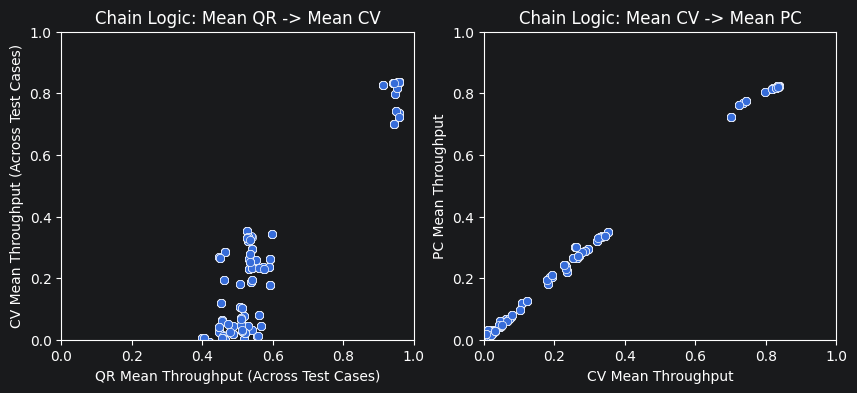

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Average across the 1000 simulations to get one value per test case
test_case_means = combined_samples.mean(axis=0)  # Result shape: (60, 3)

# 2. Plotting the relationship across ALL test cases
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# X-axis: QR Mean for each test case, Y-axis: CV Mean for each test case
sns.scatterplot(x=test_case_means[:, 0], y=test_case_means[:, 1])
plt.xlabel('QR Mean Throughput (Across Test Cases)')
plt.ylabel('CV Mean Throughput (Across Test Cases)')
plt.title('Chain Logic: Mean QR -> Mean CV')
plt.xlim(0, 1)  # Set min and max for X
plt.ylim(0, 1)  # Set min and max for Y

plt.subplot(1, 2, 2)
sns.scatterplot(x=test_case_means[:, 1], y=test_case_means[:, 2])
plt.xlabel('CV Mean Throughput')
plt.ylabel('PC Mean Throughput')
plt.title('Chain Logic: Mean CV -> Mean PC')
plt.xlim(0, 1)  # Set min and max for X
plt.ylim(0, 1)  # Set min and max for Y

# Print lengthscales for CV service
# Lower value = Higher importance/impact
print("CV Service Feature Importance (Cores, Quality, Model Size, QR_Input):")
print(model.cv_gp.covar_module.base_kernel.lengthscale)

print("PC Service Feature Importance (Cores, Quality, QR_Input):")
print(model.pc_gp.covar_module.base_kernel.lengthscale)

### Latency distribution for one Testcase and multiple MC samples

--- Expected Outcomes for Test Case 2 ---
QR Throughput:              0.42
CV Throughput (Capped):     -0.01
PC Throughput (Final):      0.01


/tmp/ipykernel_57415/1111828710.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


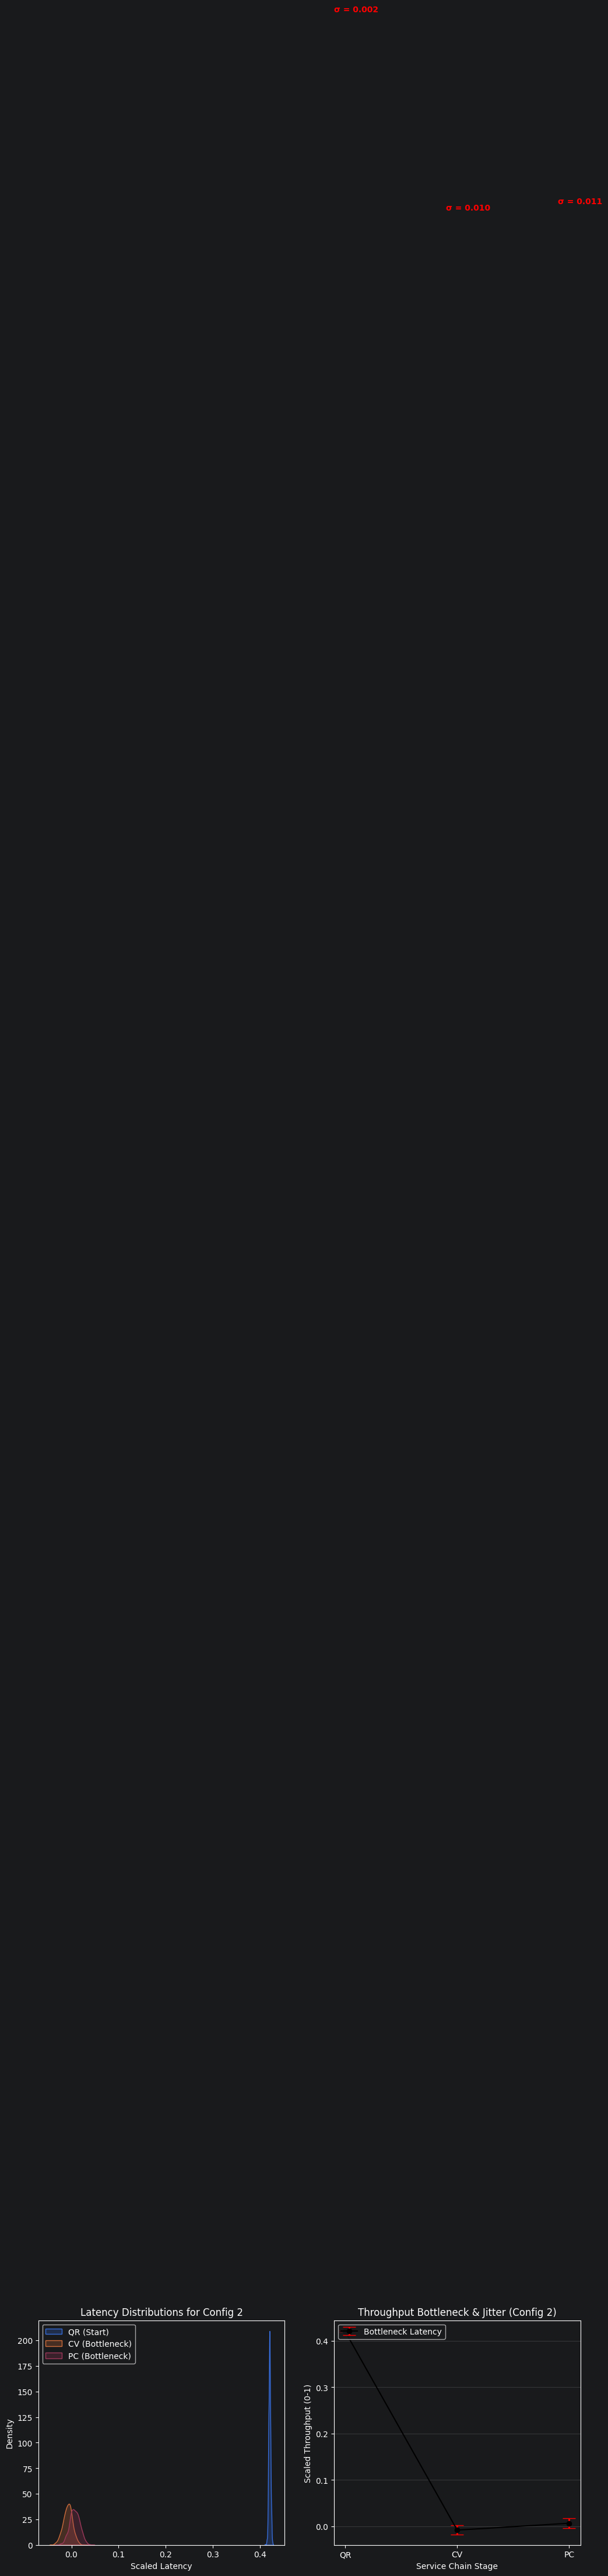

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick one specific hardware configuration (test case)
test_idx = 2
# Shape: (1000 simulations, 3 services)
single_chain_sims = combined_samples[:, test_idx, :]

# 1. Calculate Expected Outcomes (Means)
expected_qr = single_chain_sims[:, 0].mean()
expected_cv = single_chain_sims[:, 1].mean()
expected_pc = single_chain_sims[:, 2].mean()

# Change this part:
print(f"--- Expected Outcomes for Test Case {test_idx} ---")
print(f"QR Throughput:              {expected_qr:.2f}")
print(f"CV Throughput (Capped):     {expected_cv:.2f}")
print(f"PC Throughput (Final):      {expected_pc:.2f}")

# 2. Plotting the "Growth" of Latency
plt.figure(figsize=(12, 5))

# Plot A: The Probability Density for each stage
plt.subplot(1, 2, 1)
sns.kdeplot(single_chain_sims[:, 0], label='QR (Start)', fill=True)
sns.kdeplot(single_chain_sims[:, 1], label='CV (Bottleneck)', fill=True)
sns.kdeplot(single_chain_sims[:, 2], label='PC (Bottleneck)', fill=True)
# plt.axvline(threshold, color='red', linestyle='--', label='SLO Threshold')
plt.title(f"Latency Distributions for Config {test_idx}")
plt.xlabel("Scaled Latency")
plt.legend()

# Plot B: The "Staircase" of Uncertainty
plt.subplot(1, 2, 2)
stages = ['QR', 'CV', 'PC']
means = [expected_qr, expected_cv, expected_pc]
# Standard deviation as the "error bar"
stds = [single_chain_sims[:, i].std() for i in range(3)]

ebar = plt.errorbar(stages, means, yerr=stds, fmt='-o', capsize=8,
                    color='black', ecolor='red', elinewidth=2,
                    label='Bottleneck Latency')

# 3. Annotate the STD values next to the error bars
for i, stage in enumerate(stages):
    # Position the text slightly to the right of the error bar
    # We use (means[i] + stds[i]) to place it near the top whisker
    plt.text(i - 0.1, means[i] + 5, f'σ = {stds[i]:.3f}',
             va='center', fontweight='bold', color='red', fontsize=10)

plt.ylabel("Scaled Throughput (0-1)")
plt.xlabel("Service Chain Stage")
plt.title(f"Throughput Bottleneck & Jitter (Config {test_idx})")
plt.grid(axis='y', alpha=0.3)
# plt.ylim(0, max(means) + max(stds) + 20) # Give some headspace for labels
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


### Mean and std for predicted throughput across test cases

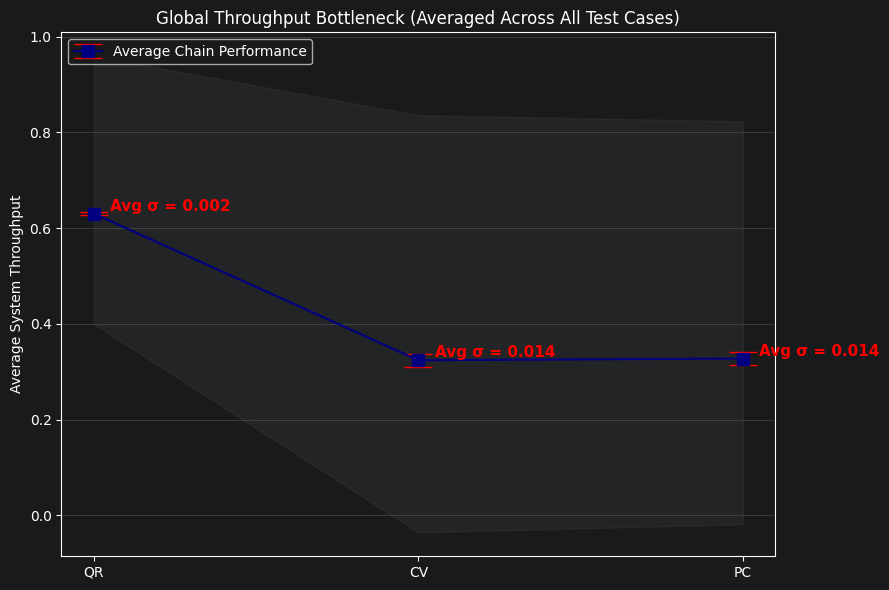

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# combined_samples shape: (1000, 60, 3)

# 1. Calculate the mean and std for EACH of the 60 test cases first
# These are (60, 3) arrays
means_per_config = combined_samples.mean(axis=0)
stds_per_config = combined_samples.std(axis=0)

# 2. Now average those across all 60 configurations to get the global profile
global_means = means_per_config.mean(axis=0)
global_stds = stds_per_config.mean(axis=0)

stages = ['QR', 'CV', 'PC']

plt.figure(figsize=(9, 6))

# 3. Plot the Global Staircase
plt.errorbar(stages, global_means, yerr=global_stds, fmt='-s', capsize=10,
             color='navy', ecolor='red', elinewidth=3, markersize=8,
             label='Average Chain Performance')

# 4. Annotate the Average Sigma for each stage
for i, stage in enumerate(stages):
    plt.text(i + 0.05, global_means[i], f'Avg σ = {global_stds[i]:.3f}',
             va='bottom', fontweight='bold', color='red', fontsize=11)

    # plt.text(i - 0.2, global_means[i] - 10, f'μ = {global_means[i]:.1f}',
    #          va='top', color='navy', fontsize=10)

plt.title("Global Throughput Bottleneck (Averaged Across All Test Cases)")
plt.ylabel("Average System Throughput")

plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper left')

# Optional: Add a shaded area showing the hardware diversity
# (the best vs worst config means)
plt.fill_between(stages,
                 means_per_config.min(axis=0),
                 means_per_config.max(axis=0),
                 color='gray', alpha=0.1, label='Hardware Spread')

plt.tight_layout()
plt.show()

### Average predicted means vs actual means

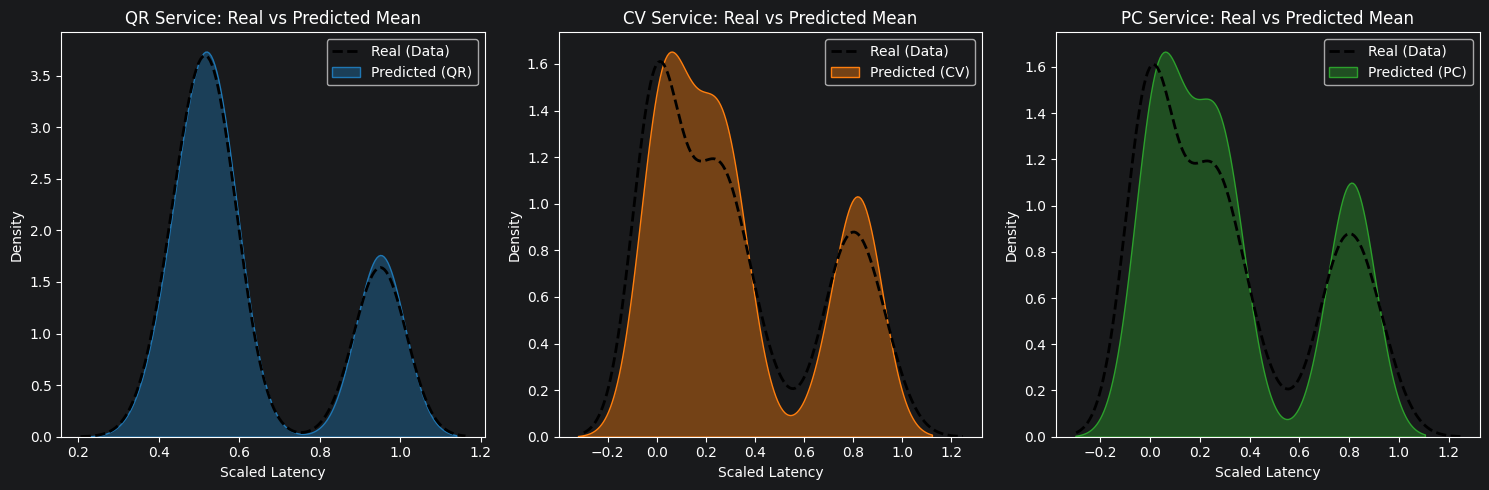

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the predicted means across all simulations for all test points
predicted_dist = combined_samples.mean(axis=0)  # resulting shape 60 * 3

# 2. Extract real data (y_train or y_test)
# Let's use y_test since it's "unseen" data
real_dist = test_y.cpu().numpy()

services = ['QR', 'CV', 'PC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

plt.figure(figsize=(15, 5))

for i, service in enumerate(services):
    plt.subplot(1, 3, i + 1)

    # Plot Real Distribution
    sns.kdeplot(real_dist[:, i], color='black', linestyle='--', label='Real (Data)', linewidth=2)

    # Plot Predicted Distribution
    sns.kdeplot(predicted_dist[:, i], color=colors[i], fill=True, label=f'Predicted ({service})', alpha=0.4)

    plt.title(f'{service} Service: Real vs Predicted Mean')
    plt.xlabel('Scaled Latency')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

### Predicted latency for test cases vs ground truth

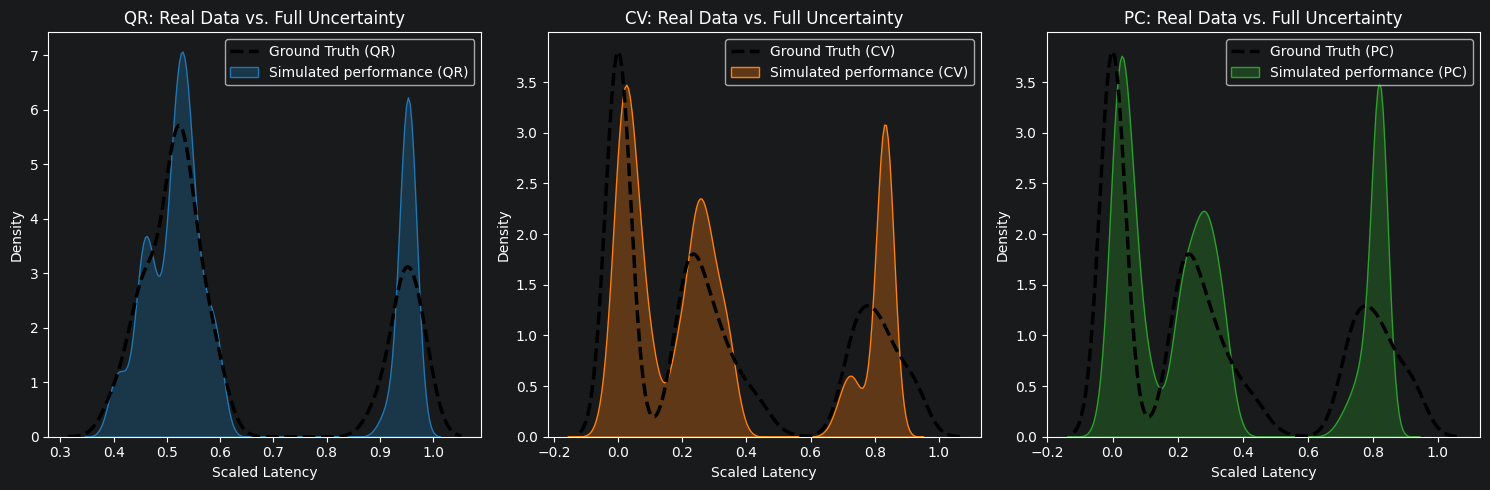

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Flatten the simulations: (1000, 60, 3) -> (60000, 3)
# This represents every "roll of the dice" the model made
all_simulated_points = combined_samples.reshape(-1, 3)

# 2. Extract real data
real_dist = test_y.cpu().numpy()

services = ['QR', 'CV', 'PC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(15, 5))

for i, service in enumerate(services):
    plt.subplot(1, 3, i + 1)

    # Plot Real Data - The actual ground truth points
    # Make it 5x more sensitive to local spikes
    sns.kdeplot(real_dist[:, i], color='black', linestyle='--',
                label=f'Ground Truth ({service})', linewidth=2.5,
                bw_adjust=0.4)

    # Plot ALL Simulations - The full range of what the GP thinks could happen
    sns.kdeplot(all_simulated_points[:, i], color=colors[i], fill=True,
                label=f'Simulated performance ({service})', alpha=0.3)

    plt.title(f'{service}: Real Data vs. Full Uncertainty')
    plt.xlabel('Scaled Latency')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

### Calculate RMSE across the pipeline

In [20]:
# --- MODEL VALIDATION ---
# Get the mean prediction for each service (mean across Monte Carlo samples)
predicted_means = combined_samples.mean(axis=0)
actual_y = test_y.cpu().numpy()

# Calculate Error for each service
for i, name in enumerate(['QR', 'CV', 'PC']):
    rmse = np.sqrt(np.mean((predicted_means[:, i] - actual_y[:, i]) ** 2))
    print(f"{name} Service RMSE: {rmse:.4f}")

QR Service RMSE: 0.0133
CV Service RMSE: 0.0761
PC Service RMSE: 0.0766
